# IMC Prosperity 4 — Team SMASHCOINS

**Final standing: 1,032nd of 18,803 teams (top 5.5%), with 211,804 XIRECs in Phase 2.** Best standing: 772nd, after Round 4.

This notebook is the companion to our written report (`../report/report.pdf`). It walks through what we built in each round, shows the research behind it, and ends with a post-mortem that re-runs the statistical checks we wish we had run during the competition.

| Member | Programme (HKUST) | Main contribution |
|---|---|---|
| POON Ka Hang (Jack) | BEng, Computer Science and Mathematics (double major), Business minor | Rounds 1–2 algorithm; options and volatility-smile strategies (Rounds 3–5); Round 5 product classification |
| SIT Chak Hong (Ivan) | BSc, Biotechnology and Mathematics (double major), Business minor | Non-options strategies from Round 3 (`HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`); Round 5 products without a clear strategy |
| LIN Hao Kun (Jacky) | BEng, Computer Science, Extended Major in Artificial Intelligence | Manual trading, Rounds 3–5 |
| CHAN Yui San (Terrence) | BSc, Physics | Manual trading, Rounds 3–5 |

## 1. Results

Prosperity 4 ran in two phases. Rounds 1–2 were qualifiers: teams needed a net profit of 200,000 XIRECs to continue, and the leaderboard reset for Phase 2 (Rounds 3–5). We did not record our Round 1 or Round 2 profit, so those cells are blank rather than estimated.

| Round | Phase | Algorithmic PnL | Manual PnL | Round PnL | Overall rank after round |
|---|---|---|---|---|---|
| 1 | 1 | not recorded | not recorded | not recorded | — |
| 2 | 1 | not recorded | not recorded | not recorded | qualified for Phase 2 |
| 3 | 2 | 37,318 (879th in round) | 75,529 (230th in round) | 112,847 | 845 |
| 4 | 2 | 37,236 (995th in round) | 45,309 (445th in round) | 82,544 | **772** |
| 5 | 2 | 39,567 | −23,154 | 16,413 | **1,032 (final)** |

Phase 2 cumulative PnL was 195,391 XIRECs after Round 4 and 211,804 after Round 5.

![Official Round 4 results](../figures/r4_official_results.png)

## 2. Rounds 1–2: market making (Jack)

Products: `ASH_COATED_OSMIUM` (described as volatile, possibly with a hidden pattern) and `INTARIAN_PEPPER_ROOT` (steady, slow-growing), position limit 80 each. Round 2 kept the products and added a blind auction for 25% more order-book volume via a `bid()` function.

Our Round 1 code was overwritten when we edited it into Round 2, so `../code/round2_market_maker.py` is the surviving version. It is a market maker with:

- a **volume-weighted mid** as the raw fair price, smoothed by a per-product **EMA** (slow for osmium, fast for pepper root);
- an **inventory skew** that shifts fair value against the current position;
- an **adaptive spread** that widens with a 10-tick rolling volatility;
- **taking** any quote at least half a tick through skewed fair value, then **penny-jumping** the best bid and ask without crossing our target edge.

Two things we would change, both visible in the code: the strategy capped positions at **20** when the exchange allowed **80**, and it had **no `bid()` function**, which the rules treat as a bid of 0 for extra market access.

## 3. Round 3: fair-value models, the first volatility smile, and manual auctions

New products: `HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`, and ten call vouchers on the extract (`VEV_4000` … `VEV_6500`).

**Ivan — `HYDROGEL_PACK` and the underlying.** He compared several fair-value estimators (Kalman filter, VWAP, a Bayesian update from trade prints) and a mean-reversion rule. The submitted algorithm (`../code/round3_bayesian_mean_reversion.py`) updates fair value with a precision-weighted Bayesian step for each market trade (bigger trades count more), enters when price deviates from fair value by a threshold scaled by recent volatility, waits through a cooldown, and exits when price crosses back.

![Fair-value models on HYDROGEL_PACK](../figures/r3_hydrogel_fair_value_models.png)

**Jack — the vouchers.** Implied volatility was backed out of each voucher with Black–Scholes and plotted against log-moneyness scaled by √TTE, which collapsed the strikes onto one parabola (first fit, with m = ln(S/K)/√T: 0.1768 m² + 0.006588 m + 0.1946; the chart below plots ln(K/S), so its linear term has the opposite sign). Across 300,000 observations the deviation from the curve averaged −0.090 with a standard deviation of 0.206. The trading version was not ready for Round 3, so the submitted file only mirrored the underlying signal on four strikes — a directional overlay rather than a volatility trade.

![Round 3 volatility smile](../figures/r3_vev_volatility_smile.png)

**Jacky and Terrence — manual.** For the first bid, assuming counterparties' reserve prices were uniform between 670 and 920 and that inventory could be resold at 920, expected profit per counterparty peaked at bids of 790–795 (about 63.7 each); they chose 795 for the higher fill probability. The manual side earned +75,529 this round (230th). For the second bid, where payoff depended on other teams, they estimated where the field's average bid would land and whether the public would bid above or below it.

## 4. Round 4: the implied-volatility smile scalper

`../code/round4_iv_smile_scalper.py` is Jack's options component. Each tick it:

1. computes **fair IV** for each strike from the fitted smile, IV = 0.1762 m² + 0.007389 m + 0.1946 with m = ln(S/K)/√T;
2. inverts the market mid to **market IV** by bisection (pure Python with the standard `math` library; SciPy wasn't supported);
3. trades the **IV residual** with hysteresis: enter beyond ±1.5 vol points, hold in between, exit inside ±0.5;
4. sizes by conviction (25 lots at the threshold, up to 150) and walks the book only up to the model price;
5. enforces a **portfolio delta budget** and hedges the forward-looking delta with the underlying.

Deep in-the-money strikes (`VEV_4000`, `VEV_4500`) were excluded: with vega near zero, their implied volatility was numerically unstable.

The cell below re-implements the pricing core and checks it.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

def ncdf(x):
    return 0.5 * math.erfc(-x / math.sqrt(2))

def bs_call(S, K, T, v):
    if T < 1e-9 or v < 1e-9:
        return max(0.0, S - K)
    sq = v * math.sqrt(T)
    d1 = (math.log(S / K) + 0.5 * v * v * T) / sq
    return S * ncdf(d1) - K * ncdf(d1 - sq)

def implied_vol(price, S, K, T, lo=1e-4, hi=4.0):
    if price <= max(0.0, S - K) + 0.01 or bs_call(S, K, T, hi) < price:
        return float("nan")
    for _ in range(80):
        m = 0.5 * (lo + hi)
        if bs_call(S, K, T, m) > price:
            hi = m
        else:
            lo = m
    return 0.5 * (lo + hi)

# Round trip: price at a known vol, then recover it
S, T = 5250.0, 7 / 252
for K in (5000, 5250, 5500, 6000):
    p = bs_call(S, K, T, 0.21)
    print(f"K={K}: price={p:8.3f}  recovered IV={implied_vol(p, S, K, T):.4f}")
print("K=6000 returns NaN by design: prices within 0.01 of intrinsic value are rejected,")
print("which is why the bot skips near-worthless out-of-the-money vouchers.")

K=5000: price= 256.662  recovered IV=0.2100
K=5250: price=  73.302  recovered IV=0.2100
K=5500: price=   8.045  recovered IV=0.2100
K=6000: price=   0.003  recovered IV=nan
K=6000 returns NaN by design: prices within 0.01 of intrinsic value are rejected,
which is why the bot skips near-worthless out-of-the-money vouchers.


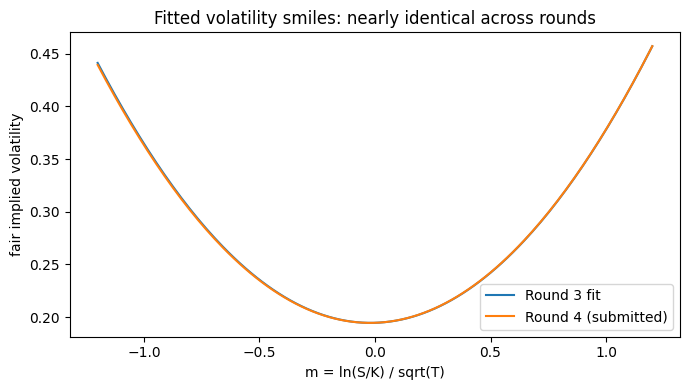

Worst-case option delta: 8 x 200 x 0.5 = 800 vs hedge capacity 200 -> budget set to 175


In [2]:
smile_r3 = (0.1768, 0.006588, 0.1946)    # Round 3 fit, converted to m = ln(S/K)/sqrt(T)
smile_r4 = (0.1762,  0.007389, 0.1946)   # used in the Round 4 submission
m = np.linspace(-1.2, 1.2, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for (a, b, c), lab in [(smile_r3, "Round 3 fit"), (smile_r4, "Round 4 (submitted)")]:
    ax.plot(m, a * m**2 + b * m + c, label=lab)
ax.set_xlabel("m = ln(S/K) / sqrt(T)")
ax.set_ylabel("fair implied volatility")
ax.set_title("Fitted volatility smiles: nearly identical across rounds")
ax.legend()
plt.tight_layout()
plt.show()

# The "delta wall": why a portfolio delta budget was needed
strikes, cap, avg_delta, hedge_limit = 8, 200, 0.5, 200
print(f"Worst-case option delta: {strikes} x {cap} x {avg_delta} = {strikes*cap*avg_delta:.0f}"
      f" vs hedge capacity {hedge_limit} -> budget set to 175")

![Round 4 smile refit](../figures/r4_vev_volatility_smile_refit.png)

**Round 4 result.** Algorithmic +37,236 (995th in the round); manual +45,309 (445th). Overall rank improved from 845 to **772**, our best.

**Round 4 manual.** Jacky and Terrence priced every contract on `AETHER_CRYSTAL` with a Monte Carlo engine (`../code/round4_manual_options_engine.py`) and bought a long-volatility portfolio: two 50 calls and one 50 put, a short 60 call, 40 and 35 puts as protection, and a two-week 50 call. The engine counted the two- and three-week expiries as 14 and 21 days, but the rules defined them as 10 and 15 trading days. The cell below shows what that did to the model values.

In [3]:
# Round 4 manual: zero-drift GBM, 251% annual vol, 4 steps per trading day, 252-day year (the official rules)
def gbm_paths(days, n=50_000, S0=50.0, sigma=2.51, seed=42):
    dt = 1 / (252 * 4)
    z = np.random.default_rng(seed).standard_normal((n, days * 4))
    return S0 * np.exp(np.cumsum(-0.5 * sigma**2 * dt + sigma * np.sqrt(dt) * z, axis=1))

for label, days in [("team engine, 21 days", 21), ("official rules, 15 trading days", 15)]:
    ST = gbm_paths(days)[:, -1]
    call50 = np.maximum(ST - 50, 0).mean()
    binput = np.where(ST < 40, 10.0, 0.0).mean()
    print(f"{label:32s} 3-week 50 call: {call50:5.2f} (quote 12.03) | binary put: {binput:4.2f} (quote 5.05)")

team engine, 21 days             3-week 50 call: 14.23 (quote 12.03) | binary put: 5.21 (quote 5.05)


official rules, 15 trading days  3-week 50 call: 12.03 (quote 12.03) | binary put: 4.75 (quote 5.05)


With the official expiries, the vanilla options were fairly priced; the engine's extra time made all of them look 16–34% cheap. The real mispricing was the binary put, quoted about 6% above its value. Under the official settings the portfolio's expected profit is close to zero, so its +45,309 came from the 100 price paths the exchange simulated, not from a pricing edge.

## 5. Round 5: fifty new products

Round 5 introduced 50 products in ten families (Pebbles, Microchips, UV Visors, Robots, Panels and so on), each with a position limit of 10. Jack and Ivan split the work by product type: we screened all 50 on Hurst exponent, lag-1 autocorrelation, spread, drift, skew and kurtosis; assigned the clear cases to market making, directional holds or pairs trading; and left the unclear products to Ivan to investigate.

- **Market making** (`../code/round5_market_maker.py`) on products with negative lag-1 autocorrelation, e.g. `ROBOT_DISHES` (AC1 = −0.22). Its "wall mid" fair price and take-then-make structure were adapted from open-source Prosperity 3 code published by team Frankfurt Hedgehogs.
- **Directional holds** (`../code/round5_directional_hold.py`): maximum long or short on six products with strong linear trends in the historical data, motivated by attribute patterns (pebble drift vs. size, r = 0.92; microchip drift vs. perimeter, r = 0.91).
- **Pairs trading** on families whose spreads passed an Engle–Granger test.
- **Per-product parameter search**: for each market-making product, the best of eight parameter sets on the historical data.

![Pebbles price paths](../figures/r5_pebbles_price_paths.png)

**Round 5 manual.** A one-day news trade with a 1,000,000 budget and a fee of (v/100)² × budget per position, where v is the percentage allocated. Five of seven directional calls were right and made about +138,600 before fees, but spreading the whole budget across seven goods cost 161,800 in fees: a v% allocation needs more than a v% price move just to break even.

**Round 5 result.** Algorithmic +39,567, manual −23,154, round total +16,413. We finished **1,032nd**, down from 772nd. We did not log per-product live PnL, so we cannot say which algorithmic component contributed. The next section tests how much of our Round 5 evidence could have come from noise alone.

## 6. Post-mortem: what pure noise looks like

Each test below simulates random walks with **no signal at all** and measures how often our Round 5 evidence would appear anyway. Seeds are fixed, so the numbers match the report.

In [4]:
rng = np.random.default_rng(42)

def hurst_rs(x, min_n=16, n_sizes=12):
    x = np.asarray(x, float); N = len(x)
    sizes = np.unique(np.floor(np.logspace(np.log10(min_n), np.log10(N // 4), n_sizes)).astype(int))
    rs = []
    for n in sizes:
        k = N // n
        chunks = x[:k * n].reshape(k, n)
        dev = np.cumsum(chunks - chunks.mean(axis=1, keepdims=True), axis=1)
        R = dev.max(axis=1) - dev.min(axis=1)
        S = chunks.std(axis=1)
        ok = S > 0
        rs.append(np.mean(R[ok] / S[ok]))
    return np.polyfit(np.log(sizes), np.log(rs), 1)[0]

# A. Hurst exponent: price levels vs returns of a pure random walk
H_lvl, H_ret = [], []
for _ in range(200):
    steps = rng.normal(size=10_000)
    walk = 10_000 + np.cumsum(steps)
    H_lvl.append(hurst_rs(walk)); H_ret.append(hurst_rs(steps))
H_lvl, H_ret = np.array(H_lvl), np.array(H_ret)
print(f"A. Hurst on price LEVELS: median {np.median(H_lvl):.3f} "
      f"(90% band {np.percentile(H_lvl,5):.3f}-{np.percentile(H_lvl,95):.3f})")
print(f"   Hurst on RETURNS:      median {np.median(H_ret):.3f} "
      f"(90% band {np.percentile(H_ret,5):.3f}-{np.percentile(H_ret,95):.3f})")

# B. Linear-trend R^2 on random walks (30,000 ticks, like the Round 5 history)
T = 30_000; t = np.arange(T); r2 = []
for _ in range(2000):
    y = np.cumsum(rng.normal(size=T))
    b, a = np.polyfit(t, y, 1); res = y - (a + b * t)
    r2.append(1 - res.var() / y.var())
r2 = np.array(r2)
print(f"B. Trend R^2 on random walks: median {np.median(r2):.2f}; "
      f"P(R^2>=0.7)={np.mean(r2>=0.7):.1%}; P(R^2>=0.9)={np.mean(r2>=0.9):.1%}")
print(f"   Expected count among 50 noise products: R^2>=0.7 -> {50*np.mean(r2>=0.7):.0f}, "
      f"R^2>=0.9 -> {50*np.mean(r2>=0.9):.1f}")

# C. Correlating 5 drifts with product attributes
attrs = {
  "pebbles":    {"rank": [1,2,3,4,5], "mass": [1,2,4,8,16]},
  "microchips": {"area": [78.5,47.1,64.0,50.0,35.1], "perimeter": [31.4,25.9,32.0,30.0,27.0],
                 "sides": [100,100,4,4,3], "symmetry": [100,2,4,2,3]},
}
def corr_rows(Y, a):
    a = np.array(a, float) - np.mean(a); a /= np.linalg.norm(a)
    Yc = Y - Y.mean(axis=1, keepdims=True); Yc /= np.linalg.norm(Yc, axis=1, keepdims=True)
    return Yc @ a
sims = 100_000
D = rng.normal(size=(sims, 2, 5))
maxabs = np.zeros(sims)
for j, fam in enumerate(attrs.values()):
    for a in fam.values():
        maxabs = np.maximum(maxabs, np.abs(corr_rows(D[:, j, :], a)))
single = np.mean(np.abs(corr_rows(D[:, 0, :], [1,2,3,4,5])) >= 0.91)
print(f"C. One test, n=5: P(|r|>=0.91) = {single:.1%}; "
      f"any of our 6 attribute tests: {np.mean(maxabs>=0.91):.1%}")

# D. Choosing the best of 8 parameter sets when true edge is zero
for rho in (0.0, 0.5):
    z = rng.normal(size=(200_000, 1)) * np.sqrt(rho) + rng.normal(size=(200_000, 8)) * np.sqrt(1 - rho)
    print(f"D. Best of 8 backtests, correlation {rho:.1f}: expected PnL = +{z.max(axis=1).mean():.2f} sigma")

A. Hurst on price LEVELS: median 0.998 (90% band 0.975-1.011)
   Hurst on RETURNS:      median 0.533 (90% band 0.505-0.560)


B. Trend R^2 on random walks: median 0.44; P(R^2>=0.7)=25.8%; P(R^2>=0.9)=3.6%
   Expected count among 50 noise products: R^2>=0.7 -> 13, R^2>=0.9 -> 1.8
C. One test, n=5: P(|r|>=0.91) = 3.2%; any of our 6 attribute tests: 17.0%
D. Best of 8 backtests, correlation 0.0: expected PnL = +1.43 sigma
D. Best of 8 backtests, correlation 0.5: expected PnL = +1.01 sigma


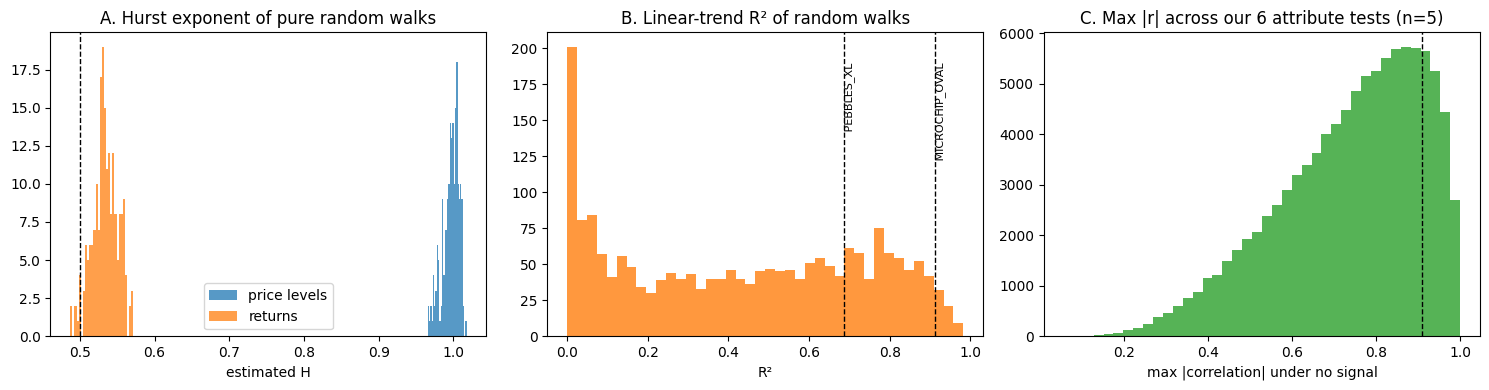

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(H_lvl, bins=30, alpha=.75, label="price levels")
ax[0].hist(H_ret, bins=30, alpha=.75, label="returns")
ax[0].axvline(0.5, color="k", ls="--", lw=1)
ax[0].set_title("A. Hurst exponent of pure random walks")
ax[0].set_xlabel("estimated H"); ax[0].legend()

ax[1].hist(r2, bins=40, color="tab:orange", alpha=.8)
for v, lab in [(0.687, "PEBBLES_XL"), (0.912, "MICROCHIP_OVAL")]:
    ax[1].axvline(v, color="k", ls="--", lw=1)
    ax[1].text(v, ax[1].get_ylim()[1]*0.9, " " + lab, rotation=90, va="top", fontsize=8)
ax[1].set_title("B. Linear-trend R² of random walks")
ax[1].set_xlabel("R²")

ax[2].hist(maxabs, bins=40, color="tab:green", alpha=.8)
ax[2].axvline(0.91, color="k", ls="--", lw=1)
ax[2].set_title("C. Max |r| across our 6 attribute tests (n=5)")
ax[2].set_xlabel("max |correlation| under no signal")
plt.tight_layout()
plt.savefig("../figures/post_mortem_null_tests.png", dpi=150)
plt.show()

**What this says about Round 5.**

- **A.** A random walk's price *level* gives a Hurst exponent of about 1.0. Our screen computed Hurst on levels, which is why 46 of 50 products were labelled "trending". On returns, a random walk gives about 0.5, which is the number that would have been informative.
- **B.** Linear trends fitted to random walks routinely look strong: about a quarter exceed R² = 0.7. Among 50 noise products, roughly 13 would pass that bar by chance. Our directional picks had R² between 0.69 and 0.91, inside what noise produces.
- **C.** With five products per family, a correlation of 0.91 happens about 3% of the time for a single test, and about 17% of the time when you try six attributes, as we did. The size and perimeter patterns were reasonable hypotheses, not discoveries.
- **D.** Picking the best of eight parameter sets lifts the expected backtest of a strategy with **zero** edge by 1.0–1.4 standard deviations. Our per-product backtest numbers were therefore optimistic by construction.

None of this proves the Round 5 strategies were wrong. It shows our evidence could not tell them apart from noise, and that is what we would test first next time.

## 7. What we would do differently

1. **Hold out a day.** Fit on two days of history, then check that the signal survives on the third before trading it.
2. **Test returns, not prices.** Use Hurst or variance ratios on returns, and require a trend to persist out of sample, not just a high R².
3. **Log live PnL by product and component**, so a weak round can be diagnosed.
4. **Use the full position limit** and implement every mechanism the round offers (our Round 2 file had a cap of 20 against a limit of 80 and no `bid()`).
5. **Size to the fee.** In Round 5's manual challenge we spent the full budget and paid more in fees than the positions earned.
6. **Check units against the rules.** In Round 4's manual challenge, counting expiries in calendar days made every vanilla option look cheap.
7. **Keep what worked:** the delta budget and entry/exit hysteresis in Round 4, and the manual team's Round 3 bidding analysis, which ranked 230th.

*Research scripts and code were developed with help from AI coding assistants; strategy choices, parameters and submissions were our own.*